## Librerias 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

In [2]:
np.random.seed(42)

# Introducción al modelo de Black-Scholes

## Contexto: ¿por qué necesitamos un modelo?

En finanzas, uno de los problemas fundamentales es determinar el precio justo de un derivado, por ejemplo, una opción.

Un derivado es un instrumento financiero cuyo valor depende del comportamiento de otro activo, llamado subyacente (por ejemplo, una acción).

Por ejemplo, una opción call europea tiene como payoff:

$$
\max(S_T - K, 0),
$$

donde:

- $S_T$ es el precio del activo al vencimiento,
- $K$ es el precio de ejercicio.

El problema central es:

> ¿Cuánto vale hoy ese payoff futuro incierto?

##  Idea clave: valuación bajo neutralidad al riesgo

Bajo el principio de no arbitraje, el precio de un derivado puede expresarse como:

$$
V_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{Payoff}]
$$

donde:

- $V_0$ es el precio hoy,
- $r$ es la tasa libre de riesgo,
- $T$ es el tiempo al vencimiento,
- $\mathbb{Q}$ es la medida neutral al riesgo.

Esto significa que el precio del derivado es el valor presente del payoff esperado.

## Supuesto fundamental: dinámica del subyacente

El modelo de Black-Scholes asume que el precio del activo sigue un **movimiento browniano geométrico**:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t
$$

donde:

- $S_t$ es el precio en el tiempo $t$,
- $\mu$ es la tasa de crecimiento,
- $\sigma$ es la volatilidad,
- $W_t$ es un movimiento browniano.

Bajo la medida neutral al riesgo, esta ecuación se transforma en:

$$
dS_t = r S_t\,dt + \sigma S_t\,dW_t
$$

Esto implica que el rendimiento esperado del activo es igual a la tasa libre de riesgo.

## Solución del modelo

La solución de esta ecuación diferencial estocástica es:

$$
S_T = S_0 \exp\left[\left(r - \frac{1}{2}\sigma^2\right)T + \sigma \sqrt{T} Z\right]
$$

donde:

$$
Z \sim N(0,1)
$$

Esto implica que el precio del activo al vencimiento es **lognormal**.

## Fórmula de Black-Scholes


Bajo estos supuestos, se puede obtener una fórmula cerrada para el precio de una opción europea.

### Call europea


$$
C_0 = S_0 N(d_1) - K e^{-rT} N(d_2)
$$

### Put europea

$$
P_0 = K e^{-rT} N(-d_2) - S_0 N(-d_1)
$$

donde:

$$
d_1 = \frac{\ln(S_0/K) + \left(r + \frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

y $N(\cdot)$ es la función de distribución acumulada de la normal estándar.


La fórmula de Black-Scholes permite calcular el precio de una opción sin necesidad de simular escenarios.

El resultado se basa en:

- la ausencia de arbitraje,
- la posibilidad de replicar el derivado con una cartera,
- y el uso de la medida neutral al riesgo.

En este contexto, el precio de la opción refleja el valor esperado de su payoff, ajustado por el tiempo y el riesgo.


## Supuestos del modelo

El modelo de Black-Scholes se basa en varios supuestos importantes:

- no hay arbitraje,
- no hay costos de transacción,
- los mercados son líquidos,
- la tasa libre de riesgo es constante,
- la volatilidad es constante,
- el activo no paga dividendos (en la versión básica),
- la opción es europea.

Estos supuestos simplifican el problema y permiten obtener una solución analítica.

## Limitaciones

Aunque Black-Scholes es muy poderoso, tiene limitaciones:

- la volatilidad real no es constante,
- los mercados tienen fricciones,
- no todos los derivados tienen fórmulas cerradas,
- no sirve directamente para derivados dependientes de trayectoria.

Por ello, en muchos casos se utilizan métodos numéricos como Monte Carlo.


El modelo de Black-Scholes transforma el problema de valuación en el cálculo de una esperanza bajo un modelo probabilístico específico.

Monte Carlo, por su parte, utiliza simulación para aproximar esa misma esperanza cuando no existe una fórmula cerrada.

Por ello, ambos enfoques están profundamente conectados.

## Comparación entre Black-Scholes y Simulación Monte Carlo

| Característica | Black-Scholes | Monte Carlo |
|---------------|-------------|------------|
| **Tipo de método** | Analítico (fórmula cerrada) | Numérico (simulación) |
| **Idea principal** | Resolver la esperanza de forma exacta | Aproximar la esperanza mediante promedios simulados |
| **Base teórica** | Ecuaciones diferenciales + no arbitraje | Ley de los Grandes Números y Teorema Central del Límite |
| **Velocidad** | Muy rápida | Más lenta (requiere muchas simulaciones) |
| **Precisión** | Exacta dentro del modelo | Aproximada (con error estadístico) |
| **Error** | No tiene error numérico | Error $\sim \frac{1}{\sqrt{n}}$ |
| **Flexibilidad** | Baja | Muy alta |
| **Tipo de derivados** | Europeos simples | Complejos y exóticos |
| **Dependencia de trayectoria** | No | Sí (puede manejar path-dependent) |
| **Número de variables** | Limitado | Maneja alta dimensión fácilmente |
| **Implementación** | Fórmulas directas | Simulación + promedio |
| **Interpretación** | Resultado matemático exacto | Promedio de escenarios simulados |
| **Uso típico** | Benchmark teórico | Problemas complejos sin solución cerrada |

Ambos métodos parten del mismo principio:

$$
V_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{Payoff}]
$$

pero difieren en cómo se calcula la esperanza:

- **Black-Scholes**: la calcula de forma analítica.
- **Monte Carlo**: la aproxima mediante simulación.

# Transición de Black-Scholes hacia Simulación Monte Carlo

El modelo de Black-Scholes es fundamental porque muestra que el precio de un derivado puede escribirse como el valor presente de un payoff esperado bajo la medida neutral al riesgo.

En forma general:

$$
V_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{Payoff}]
$$

En algunos casos, como una call o una put europea bajo los supuestos clásicos de Black-Scholes, esta esperanza puede resolverse de manera analítica y conduce a una fórmula cerrada.

Sin embargo, en muchos problemas financieros reales esto ya no es posible. Por ejemplo:

- cuando el derivado tiene un payoff más complejo,
- cuando depende de toda la trayectoria del subyacente,
- cuando intervienen varios factores de riesgo,
- o cuando el modelo del mercado ya no permite una solución explícita.

En esas situaciones, la idea financiera sigue siendo la misma: el precio continúa siendo una esperanza descontada. Lo que cambia es el método para calcularla.

Aquí es donde entra la **simulación Monte Carlo**.

En lugar de resolver la esperanza analíticamente, Monte Carlo la aproxima numéricamente mediante los siguientes pasos:

1. simular muchos escenarios posibles del subyacente -> Simulamos nuetras $X_i$
2. calcular el payoff en cada escenario -> Evaluamos en nuetras $g(X_i)$
3. promediar esos payoffs -> $\mathbb{E} (g(X_i))$
4. y descontar el resultado al presente.

Es decir, si Black-Scholes calcula exactamente la esperanza dentro de un modelo específico, Monte Carlo aproxima esa misma esperanza mediante simulación.

Por lo tanto, Monte Carlo puede verse como una extensión natural de la lógica de Black-Scholes: ambos parten del mismo principio de valuación, pero Monte Carlo permite trabajar en contextos donde ya no existe una fórmula cerrada.

- **Black-Scholes**: da una fórmula exacta cuando el problema es suficientemente simple y los supuestos lo permiten.
- **Monte Carlo**: aproxima el precio mediante simulación cuando el problema ya no puede resolverse de forma analítica.

Así, Monte Carlo no reemplaza a Black-Scholes, sino que amplía su alcance.

# Valuación de derivados con simulación Monte Carlo

Se trabajará con:

- una **call europea**,
- una **put europea**,
- la comparación con la fórmula cerrada de **Black-Scholes**,
- y algunas **técnicas de reducción de varianza**.

El objetivo es mostrar que, bajo ciertos supuestos, el precio de un derivado puede aproximarse mediante simulación Monte Carlo como el valor presente del payoff promedio.

En general, bajo la medida neutral al riesgo:

$$
V_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{Payoff}]
$$

Por lo tanto, si se pueden simular escenarios futuros del subyacente, se puede aproximar el precio del derivado.

Supondremos que el precio del activo subyacente sigue un movimiento browniano geométrico bajo la medida neutral al riesgo. El modelo Black-Scholes que vimos arriba 

### Call europea

Una call europea da el derecho de comprar el activo al precio de ejercicio $K$ en la fecha de vencimiento $T$.

Su payoff es:

$$
\max(S_T - K, 0)
$$

Por lo tanto, su precio teórico bajo neutralidad al riesgo es:

$$
C_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\max(S_T-K,0)]
$$

Esto encaja perfectamente con el enfoque Monte Carlo:

1. simular muchos valores de $S_T$,
2. calcular el payoff en cada escenario,
3. promediar,
4. descontar al presente.

### Put europea

Una put europea da el derecho de vender el activo al precio de ejercicio $K$ en la fecha de vencimiento $T$.

Su payoff es:

$$
\max(K - S_T, 0)
$$

Por lo tanto, su precio es:

$$
P_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\max(K-S_T,0)]
$$

La lógica de simulación es exactamente la misma que para la call. La única diferencia es la forma del payoff.

Cuando se cumplen los supuestos del modelo Black-Scholes, el precio de una call y una put europeas puede calcularse en forma cerrada.

**Call europea**

$$
C_0 = S_0 N(d_1) - K e^{-rT} N(d_2)
$$

**Put europea**

$$
P_0 = K e^{-rT}N(-d_2) - S_0 N(-d_1)
$$

donde:

$$
d_1 = \frac{\ln(S_0/K) + \left(r + \frac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

Aquí, $N(\cdot)$ representa la función de distribución acumulada de una normal estándar.

Estas fórmulas son útiles porque nos permiten comparar la estimación Monte Carlo con el valor teórico exacto bajo Black-Scholes.

In [3]:
# Parámetros base
S0 = 100      # precio spot
K = 105       # strike
r = 0.05      # tasa libre de riesgo
sigma = 0.20  # volatilidad
T = 1.0       # vencimiento en años
n = 100000    # número de simulaciones

Primero definimos funciones para:

- la función de distribución acumulada de la normal estándar,
- el precio Black-Scholes de la call,
- y el precio Black-Scholes de la put.

Esto permitirá comparar directamente los resultados de Monte Carlo contra la solución cerrada.

In [4]:
def N(x):
    """CDF de la normal estándar."""
    return 0.5 * (1.0 + erf(x / np.sqrt(2.0)))

def bs_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * N(d1) - K * np.exp(-r * T) * N(d2)

def bs_put_price(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * N(-d2) - S0 * N(-d1)

### Simulación Monte Carlo para la call europea

Usaremos la representación lognormal del precio terminal:

$$
S_T = S_0 \exp\left[\left(r-\frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}Z\right]
$$

con:

$$
Z \sim N(0,1)
$$

Después calcularemos el payoff:

$$
\max(S_T-K,0)
$$

y finalmente descontaremos el promedio.

In [5]:
# Simulación del precio terminal
Z = np.random.normal(0, 1, size=n)
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Payoff call
payoff_call = np.maximum(ST - K, 0)

# Precio Monte Carlo call
call_mc = np.exp(-r * T) * np.mean(payoff_call)

# Error estándar
call_se = np.exp(-r * T) * np.std(payoff_call, ddof=1) / np.sqrt(n)

# Intervalo de confianza
call_ic = (call_mc - 1.96 * call_se, call_mc + 1.96 * call_se)

print("Call Monte Carlo:", call_mc)
print("Error estándar  :", call_se)
print("IC 95%          :", call_ic)

Call Monte Carlo: 8.041620675135178
Error estándar  : 0.041760503048296385
IC 95%          : (np.float64(7.959770089160517), np.float64(8.123471261109838))


In [6]:
call_bs = bs_call_price(S0, K, r, sigma, T)

print("Call Black-Scholes:", call_bs)
print("Diferencia MC - BS:", call_mc - call_bs)

Call Black-Scholes: 8.021352235143176
Diferencia MC - BS: 0.020268439992001674


En este caso:

- **Monte Carlo** produce una aproximación numérica,
- **Black-Scholes** produce el valor exacto bajo los supuestos del modelo.

Si el número de simulaciones es suficientemente grande, el valor Monte Carlo debe quedar cercano al precio Black-Scholes.

Además, el intervalo de confianza Monte Carlo debería contener aproximadamente al valor teórico si la simulación es suficientemente precisa.

### Simulación Monte Carlo para la put europea

Ahora repetimos la misma lógica para la put.

Su payoff es:

$$
\max(K-S_T, 0)
$$

y el precio se estima como:

$$
\hat{P}_0 = e^{-rT}\frac{1}{n}\sum_{i=1}^n \max(K-S_T^{(i)},0)
$$

In [7]:
# Payoff put
payoff_put = np.maximum(K - ST, 0)

# Precio Monte Carlo put
put_mc = np.exp(-r * T) * np.mean(payoff_put)

# Error estándar
put_se = np.exp(-r * T) * np.std(payoff_put, ddof=1) / np.sqrt(n)

# Intervalo de confianza
put_ic = (put_mc - 1.96 * put_se, put_mc + 1.96 * put_se)

print("Put Monte Carlo :", put_mc)
print("Error estándar  :", put_se)
print("IC 95%          :", put_ic)

Put Monte Carlo : 7.898061476943745
Error estándar  : 0.03276850865897547
IC 95%          : (np.float64(7.833835199972153), np.float64(7.962287753915337))


In [8]:
put_bs = bs_put_price(S0, K, r, sigma, T)

print("Put Black-Scholes:", put_bs)
print("Diferencia MC - BS:", put_mc - put_bs)

Put Black-Scholes: 7.9004418077181455
Diferencia MC - BS: -0.0023803307744003632


La call y la put europeas tienen estructuras de payoff distintas:

**Call**
$$
\max(S_T-K,0)
$$

**Put**
$$
\max(K-S_T,0)
$$

La call gana cuando el precio final del activo supera el strike.

La put gana cuando el precio final del activo queda por debajo del strike.

Aunque ambas se valoran con la misma estructura Monte Carlo, sus distribuciones de payoff pueden ser bastante distintas, y por ello sus errores estándar también pueden cambiar.

Bajo ausencia de arbitraje, la call y la put europeas satisfacen la paridad put-call:

$$
C_0 - P_0 = S_0 - K e^{-rT}
$$

Esta relación es muy importante porque conecta los precios de ambos derivados.

Como Monte Carlo nos da estimaciones para call y put, podemos verificar numéricamente si esta relación se cumple aproximadamente.

In [9]:
lhs_mc = call_mc - put_mc
rhs_theoretical = S0 - K * np.exp(-r * T)

lhs_bs = call_bs - put_bs

print("Paridad con Monte Carlo (C - P):", lhs_mc)
print("Paridad con Black-Scholes     :", lhs_bs)
print("S0 - K exp(-rT)               :", rhs_theoretical)
print("Error Monte Carlo             :", lhs_mc - rhs_theoretical)

Paridad con Monte Carlo (C - P): 0.1435591981914328
Paridad con Black-Scholes     : 0.12091042742503078
S0 - K exp(-rT)               : 0.12091042742503078
Error Monte Carlo             : 0.022648770766402038


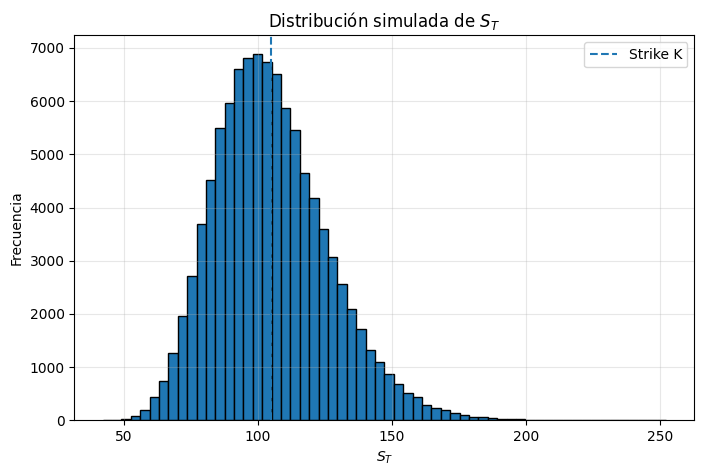

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(ST, bins=60, edgecolor="black")
plt.axvline(K, linestyle="--", label="Strike K")
plt.title("Distribución simulada de $S_T$")
plt.xlabel("$S_T$")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Esta gráfica muestra la distribución simulada de $S_T$. La línea del strike divide los escenarios donde la opción tiene valor y donde no. Monte Carlo usa todos estos escenarios, calcula el payoff en cada uno y los promedia. Solo la parte derecha de la distribución contribuye al valor de la call, lo que explica por qué la volatilidad aumenta el precio de la opción